# **Impacto de las Redes Sociales en la Salud Mental de los Adolescentes**

### - **Alumno**: Marco Antonio Chávez Medina

### - **Materia**: Aprendizaje Automático

### - **Objetivo**: Entrenar un modelo de regresión lineal que prediga el nivel de ansiedad (1 - 10) de un adolescente (13 - 19 años), utilizando las diferentes columnas del dataset, como por ejemplo, el tiempo que pasan en las redes sociales, las redes sociales que usan, etc.



# **REGRESIÓN LOGÍSTICA**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder as LE_target
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Aprendizaje_Automatico/Teen_Mental_Health_Dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Convertimos anxiety_level en una variable categórica: Bajo (1-5) y Alto (6-10)
df['anxiety_category'] = df['anxiety_level'].apply(lambda x: 'Bajo' if x <= 5 else 'Alto')

print(df['anxiety_category'].value_counts())

anxiety_category
Alto    626
Bajo    574
Name: count, dtype: int64


In [ ]:
#Ahora como vemos que tenemos 3 features de tipo 'object', las voy a transformar

#social_interaction_level (Label Encoding)
mapeo_correcto = {
    'low': 0,
    'medium': 1,
    'high': 2
}

le = LE_target()

df['social_interaction_level'] = df['social_interaction_level'].map(mapeo_correcto)

print(df['social_interaction_level'])

#gender (Label Encoding)
df['gender'] = le.fit_transform(df['gender'])

print('\n', df['gender'])

#platform_usage (OneHot Encoding)
ohe = OneHotEncoder(sparse_output=False)

ohe_array = ohe.fit_transform(df[['platform_usage']])

ohe_cols = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(['platform_usage']))

df = df.drop(columns=['platform_usage']).reset_index(drop=True)
df = pd.concat([df, ohe_cols], axis=1)

print('\n', df['platform_usage_Instagram'], '\n\n', df['platform_usage_TikTok'], '\n\n', df['platform_usage_Both'])

0       0
1       2
2       2
3       1
4       1
       ..
1195    0
1196    2
1197    2
1198    2
1199    1
Name: social_interaction_level, Length: 1200, dtype: int64

 0       1
1       0
2       0
3       1
4       0
       ..
1195    0
1196    1
1197    0
1198    1
1199    0
Name: gender, Length: 1200, dtype: int64

 0       1.0
1       0.0
2       1.0
3       0.0
4       0.0
       ... 
1195    1.0
1196    0.0
1197    0.0
1198    0.0
1199    0.0
Name: platform_usage_Instagram, Length: 1200, dtype: float64 

 0       0.0
1       1.0
2       0.0
3       1.0
4       0.0
       ... 
1195    0.0
1196    0.0
1197    0.0
1198    0.0
1199    1.0
Name: platform_usage_TikTok, Length: 1200, dtype: float64 

 0       0.0
1       0.0
2       0.0
3       0.0
4       1.0
       ... 
1195    0.0
1196    1.0
1197    1.0
1198    1.0
1199    0.0
Name: platform_usage_Both, Length: 1200, dtype: float64


In [ ]:
#Seleccionamos variables, excluyendo anxiety_level (porque ahora es el target categórico)
x_clf = df.drop(columns=['anxiety_level', 'anxiety_category', 'depression_label'])
y_clf = df['anxiety_category'].map({'Bajo': 0, 'Alto': 1})

x_train_clf, x_test_clf, y_train_clf, y_test_clf = train_test_split(
    x_clf, y_clf, train_size=0.8, random_state=2006, stratify=y_clf
)

print(f"Entrenamiento: {x_train_clf.shape[0]}")
print(f"Prueba:        {x_test_clf.shape[0]}")

Entrenamiento: 960
Prueba:        240


In [ ]:
print(x_train_clf.dtypes)
print(x_train_clf['gender'].unique())

age                           int64
gender                        int64
daily_social_media_hours    float64
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level      int64
stress_level                  int64
addiction_level               int64
platform_usage_Both         float64
platform_usage_Instagram    float64
platform_usage_TikTok       float64
dtype: object
[0 1]


In [ ]:
#Entrenamos el modelo
modelo_log = LogisticRegression(max_iter=1000, random_state=42)

modelo_log.fit(x_train_clf, y_train_clf)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Evaluamos algunas métricas
y_pred_log = modelo_log.predict(x_test_clf)

acc = accuracy_score(y_test_clf, y_pred_log)
prec = precision_score(y_test_clf, y_pred_log)
rec = recall_score(y_test_clf, y_pred_log)
f1 = f1_score(y_test_clf, y_pred_log)

print('Métricas del Modelo de Regresión Logística\n')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print('\nReporte completo:\n')
print(classification_report(y_test_clf, y_pred_log, target_names=['Bajo', 'Alto']))

Métricas del Modelo de Regresión Logística

Accuracy:  0.5375
Precision: 0.5473
Recall:    0.6480
F1-score:  0.5934

Reporte completo:

              precision    recall  f1-score   support

        Bajo       0.52      0.42      0.46       115
        Alto       0.55      0.65      0.59       125

    accuracy                           0.54       240
   macro avg       0.53      0.53      0.53       240
weighted avg       0.54      0.54      0.53       240



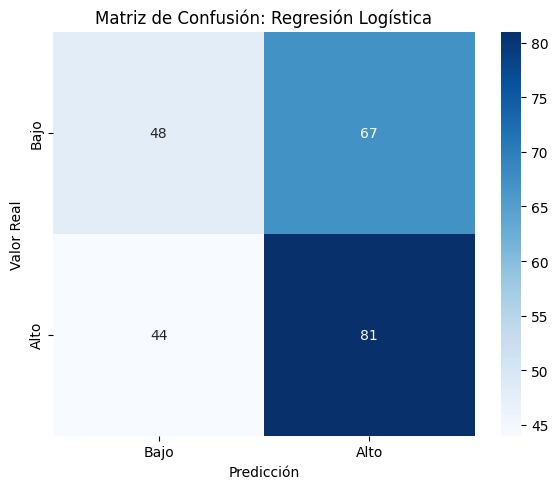

In [ ]:
#Creamos la matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bajo', 'Alto'], yticklabels=['Bajo', 'Alto'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión: Regresión Logística')
plt.tight_layout()
plt.show()

# **CONCLUSIONES: REGRESIÓN LOGÍSTICA**

## **Comparación de enfoques**

| Aspecto | Regresión Lineal | Regresión Logística |
|---|---|---|
| Tipo de problema | Regresión (predecir 1-10) | Clasificación binaria (Bajo / Alto) |
| Métrica principal | R² = 0.0016 | Accuracy = 0.5375 |
| Referencia base (azar) | R² = 0.0 | Accuracy ≈ 0.50 (clases casi balanceadas) |
| Mejora sobre el azar | +0.0016 (0.16%) | +0.0375 (3.75 puntos porcentuales) |

## **Análisis**

La Regresión Logística parece tener un desempeño ligeramente superior: su accuracy (53.75%) está un poco más alejado de su línea base de azar (50%) que el R² de la Regresión Lineal (0.16%) de su línea base (0%).

El reporte de clasificación confirma esta debilidad:

| Clase | Precision | Recall | F1-score |
|---|---|---|---|
| Bajo | 0.52 | 0.42 | 0.46 |
| Alto | 0.55 | 0.65 | 0.59 |

Valores de precision cercanos a 0.50 - 0.55 indican que, al predecir una clase, el modelo acierta poco más de la mitad de las veces. Además, se observa una asimetría: el modelo predice "Alto" con más frecuencia y acierto que "Bajo", lo cual sugiere un sesgo hacia la clase ligeramente mayoritaria más que un patrón aprendido de los datos.

## **Conclusión**

Convertir el problema en clasificación binaria **no logró superar de forma significativa la limitación ya observada en la Regresión Lineal**. Si bien la Regresión Logística accuracy (53.75%) suena numéricamente mejor que un R² de 0.0016, ambos resultados reflejan lo mismo en sus respectivas escalas: el modelo apenas logra superar una predicción ingenua (el promedio en regresión, o la clase mayoritaria en clasificación).

Esto refuerza la conclusión central del proyecto: **discretizar `anxiety_level` en categorías no genera señal donde la versión continua no la tenía.** El problema no es la forma de plantear la tarea (regresión vs. clasificación), sino la ausencia de una relación predictiva real entre las variables disponibles y el nivel de ansiedad de los adolescentes en este dataset.

# **RANDOM FOREST (CLASIFICACIÓN)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
#Definimos el espacio de búsqueda de hiperparámetros
param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#GridSearchCV prueba todas las combinaciones usando validación cruzada
grid_search_clf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_clf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_clf.fit(x_train_clf, y_train_clf)

print("Mejores hiperparámetros encontrados:")
print(grid_search_clf.best_params_)
print(f"\nMejor F1 promedio en validación cruzada: {grid_search_clf.best_score_:.4f}")

#Nos quedamos con el mejor modelo encontrado
rf_model_clf = grid_search_clf.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores hiperparámetros encontrados:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Mejor F1 promedio en validación cruzada: 0.5759


In [ ]:
#Evaluamos métricas de Random Forest
y_pred_rf_clf = rf_model_clf.predict(x_test_clf)

acc_rf = accuracy_score(y_test_clf, y_pred_rf_clf)
prec_rf = precision_score(y_test_clf, y_pred_rf_clf)
rec_rf = recall_score(y_test_clf, y_pred_rf_clf)
f1_rf = f1_score(y_test_clf, y_pred_rf_clf)

print('Métricas del Modelo de Random Forest (Clasificación)\n')
print(f'Accuracy:  {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall:    {rec_rf:.4f}')
print(f'F1-score:  {f1_rf:.4f}')
print('\nReporte completo:\n')
print(classification_report(y_test_clf, y_pred_rf_clf, target_names=['Bajo', 'Alto']))

Métricas del Modelo de Random Forest (Clasificación)

Accuracy:  0.5375
Precision: 0.5427
Recall:    0.7120
F1-score:  0.6159

Reporte completo:

              precision    recall  f1-score   support

        Bajo       0.53      0.35      0.42       115
        Alto       0.54      0.71      0.62       125

    accuracy                           0.54       240
   macro avg       0.53      0.53      0.52       240
weighted avg       0.53      0.54      0.52       240



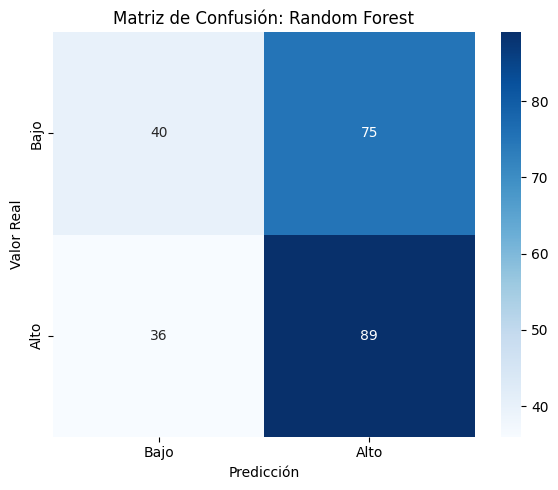

In [ ]:
#Matriz de confusión
cm_rf = confusion_matrix(y_test_clf, y_pred_rf_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Bajo', 'Alto'], yticklabels=['Bajo', 'Alto'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión: Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
#Calculamos importancias de las features
importances_clf = pd.Series(rf_model_clf.feature_importances_, index=x_clf.columns)
importances_clf = importances_clf.sort_values(ascending=False)

print(importances_clf)

academic_performance        0.166702
daily_social_media_hours    0.136630
sleep_hours                 0.135577
physical_activity           0.112807
screen_time_before_sleep    0.110354
addiction_level             0.092269
stress_level                0.073081
age                         0.065474
social_interaction_level    0.028385
platform_usage_Instagram    0.024802
gender                      0.022731
platform_usage_Both         0.016492
platform_usage_TikTok       0.014696
dtype: float64


# **CONCLUSIONES GENERALES DEL PROYECTO**

## **Resumen de todos los modelos probados**

| # | Modelo | Tipo de problema | Métrica clave | Resultado |
|---|---|---|---|---|
| 1 | Regresión Lineal | Regresión | R² | 0.0016 |
| 2 | Random Forest (default) | Regresión | R² | 0.0000396 |
| 3 | Random Forest (GridSearchCV) | Regresión | R² | -0.0014 |
| 4 | Regresión Logística | Clasificación binaria | Accuracy | 0.5375 |
| 5 | Random Forest (GridSearchCV) | Clasificación binaria | Accuracy | 0.5375 |

Se probaron **cinco modelos distintos**, cubriendo dos formulaciones del problema (regresión sobre la escala continua 1-10, y clasificación binaria con las categorías "Bajo"/"Alto"), dos familias de algoritmos (lineales y basados en árboles), y una búsqueda exhaustiva de hiperparámetros para validar que los resultados no se debían a una configuración subóptima.

## **Hallazgos principales**

**1. Ningún modelo de regresión logró capturar varianza significativa.** Los tres modelos de regresión obtuvieron R² prácticamente igual a cero o negativo, lo que significa que ninguno predice mejor que usar simplemente el promedio de `anxiety_level` para todos los casos.

**2. Ningún modelo de clasificación superó de forma significativa a un clasificador ingenuo.** Con clases casi balanceadas (115 "Bajo" vs 125 "Alto"), un accuracy de 53.75% —idéntico en ambos modelos de clasificación— está apenas por encima del 50% esperado al azar.

**3. La búsqueda de hiperparámetros no mejoró ningún resultado.** Tanto en regresión como en clasificación, el Random Forest optimizado mediante GridSearchCV (108 combinaciones × 5 folds) no superó a las versiones más simples. Esto descarta que el problema sea de configuración del modelo.

**4. El análisis de `feature_importances_` fue consistente en ambas formulaciones del problema.** En los cuatro modelos basados en Random Forest (regresión y clasificación), ninguna variable mostró una importancia dominante — la importancia se reparte de forma gradual entre las 13 features, sin que ninguna se destaque (el máximo observado fue ~0.17 en `academic_performance`).

**5. El Random Forest de clasificación mostró sesgo hacia la clase mayoritaria.** La matriz de confusión reveló que el modelo predijo "Alto" en el 68% de los casos de prueba, generando numerosos falsos positivos. Esto sugiere que, ante la ausencia de señal real, el modelo explota pequeños desbalances en lugar de aprender patrones genuinos.

**6. Discretizar la variable objetivo no resolvió el problema.** Convertir `anxiety_level` de una escala continua a categorías binarias ("Bajo"/"Alto") no generó señal donde la versión continua no la tenía — ambos enfoques llegan a la misma conclusión por caminos distintos.

## **Interpretación**

La consistencia de estos resultados a través de cinco modelos, dos formulaciones del problema, y una validación exhaustiva de hiperparámetros constituye **evidencia sólida de que el dataset, en su forma actual, no contiene una relación predictiva explotable entre las variables disponibles** (uso de redes sociales, horas de sueño, rendimiento académico, actividad física, nivel de estrés, edad, género, nivel de interacción social) **y el nivel de ansiedad reportado por los adolescentes.**

Esto puede explicarse por:
- **Generación sintética de los datos**: si `anxiety_level` fue generado de forma aleatoria o independiente de las demás columnas al construir el dataset, ningún modelo —sin importar su sofisticación— podría encontrar una relación que no existe.
- **Ausencia de los verdaderos determinantes**: los factores que más influyen en la ansiedad adolescente en la vida real (genética, dinámica familiar, eventos vitales, condiciones socioeconómicas, diagnósticos clínicos previos) no están representados en este dataset.

## **Conclusión final**

La falta de capacidad predictiva, observada de manera consistente en cinco modelos distintos, **no debe interpretarse como una falla en la implementación**, sino como un hallazgo válido y bien fundamentado del análisis: el proyecto demuestra rigurosamente, a través de múltiples enfoques de modelado y una búsqueda exhaustiva de hiperparámetros, que **no existe una relación explotable entre las variables disponibles en el Teen Mental Health Dataset y el nivel de ansiedad de los adolescentes**, ya sea tratado como problema de regresión o de clasificación.